In [172]:
import pandas as pd
df = pd.read_csv('data_transformed.csv')

# create a 'full_id' column by concatenating 'season', 'team', and 'name'
df['full_id'] = df['season'].astype(str) + ' | ' + df['team'] + ' | ' + df['name']

# only keep columns with 'pct_diff' in their name
pct_diff_cols = [col for col in df.columns if 'pct_diff' in col]
df = df[pct_diff_cols + ['full_id']]
df.set_index('full_id', inplace=True)

In [173]:
from sklearn.decomposition import PCA
pca = PCA(n_components=2)

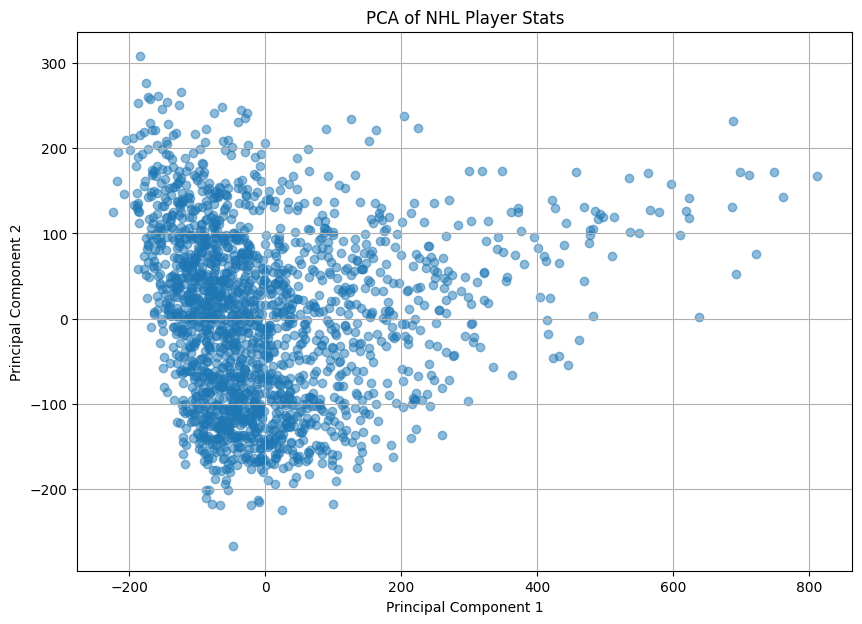

In [176]:
X = df[pct_diff_cols].values
X_pca = pca.fit_transform(X)
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 7))
plt.scatter(X_pca[:, 0], X_pca[:, 1], alpha=0.5)
plt.title('PCA of NHL Player Stats')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.grid()
plt.show()

In [180]:
# find the top 5 and bottom 5 players with the highest and lowest value in the first principal component
top_players = df.iloc[X_pca[:, 0].argsort()[-5:]]
bottom_players = df.iloc[X_pca[:, 0].argsort()[:5]]
print("Top 5 players:")
print(top_players.index.tolist())
print("\nBottom 5 players:")
print(bottom_players.index.tolist())

Top 5 players:
['2026 | ANA | Ross Johnston', '2026 | NYI | Marc Gatcomb', '2026 | VEG | Keegan Kolesar', '2024 | PHI | Nicolas Deslauriers', '2026 | CGY | Adam Klapka']

Bottom 5 players:
['2026 | NJD | Jack Hughes', '2024 | NJD | Jack Hughes', '2025 | NJD | Jack Hughes', '2026 | ANA | Troy Terry', '2024 | NYR | Artemi Panarin']


In [181]:
# find the top 5 and bottom 5 players with the highest and lowest value in the second principal component
top_players = df.iloc[X_pca[:, 1].argsort()[-5:]]
bottom_players = df.iloc[X_pca[:, 1].argsort()[:5]]
print("Top 5 players:")
print(top_players.index.tolist())
print("\nBottom 5 players:")
print(bottom_players.index.tolist())

Top 5 players:
['2025 | EDM | Leon Draisaitl', '2025 | BOS | David PastrÅ\x88Ã¡k', '2026 | ANA | Cutter Gauthier', '2024 | TOR | Auston Matthews', '2024 | MIN | Kirill Kaprizov']

Bottom 5 players:
['2024 | CGY | Chris Tanev', '2024 | CHI | Jaycob Megna', '2025 | MTL | David Savard', '2024 | NYR | Nick Bonino', '2024 | EDM | Vincent Desharnais']


In [182]:
# show all PCA for Jack Hughes
jack_hughes = df[df.index.str.contains('Jack Hughes')]
jack_hughes_pca = pca.transform(jack_hughes[pct_diff_cols].values)
print("Jack Hughes PCA:")
print(jack_hughes_pca)

Jack Hughes PCA:
[[-218.00958378  161.23321541]
 [-217.2085313   195.00801626]
 [-224.94844715  125.08888634]]


In [184]:
# show correlation between original features and principal components
correlation_matrix = pd.DataFrame(pca.components_, columns=pct_diff_cols)
print("Correlation between original features and principal components:")
print(correlation_matrix)

Correlation between original features and principal components:
   goals_per60_pct_diff  assists_per60_pct_diff  pen_min_per60_pct_diff  \
0             -0.177097               -0.176564                0.529222   
1              0.715273                0.297398                0.169205   

   shots_per60_pct_diff  blocks_per60_pct_diff  hits_per60_pct_diff  \
0             -0.062246               0.091571             0.800068   
1              0.312537              -0.470484             0.199075   

   takeaways_per60_pct_diff  giveaways_per60_pct_diff  
0                 -0.061802                 -0.034597  
1                  0.112348                  0.004565  


In [186]:
# scale PCA scores to be between 0 and 1
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

# find top 5 players with highest value in both principal components
combined_score = X_pca_scaled[:, 0] + X_pca_scaled[:, 1]
top_players_combined = df.iloc[combined_score.argsort()[-5:]]
print("Top 5 players with highest combined PCA score:")
print(top_players_combined.index.tolist())

Top 5 players with highest combined PCA score:
['2026 | ANA | Ross Johnston', '2024 | PHI | Nicolas Deslauriers', '2026 | VEG | Keegan Kolesar', '2024 | CGY | Martin Pospisil', '2026 | CGY | Adam Klapka']


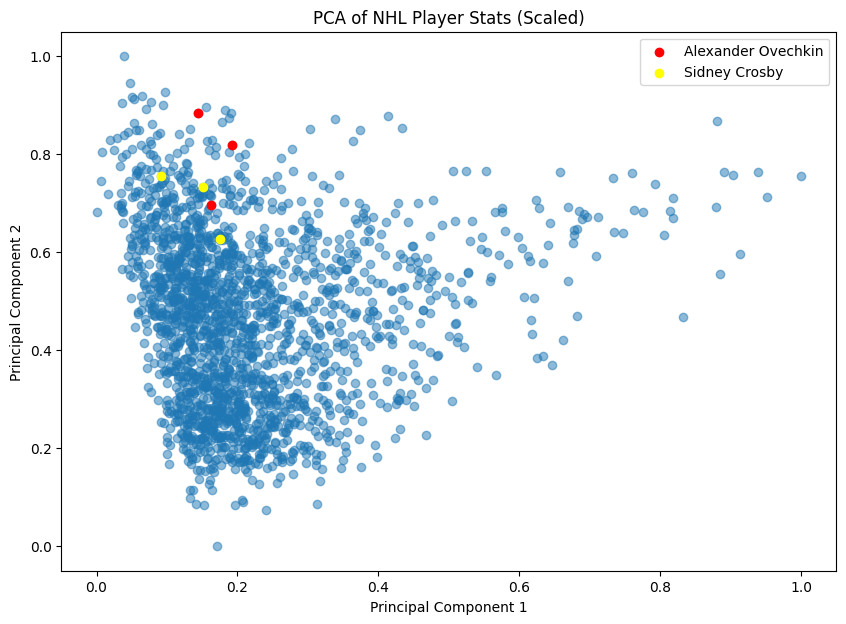

In [ ]:
# scatterplot with scaled PCA scores and all Alex Ovechkin and Sydney Crosby players highlighted
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], alpha=0.5)
ovechkin_players = df[df.index.str.contains('Alex Ovechkin')]
ovechkin_pca_scaled = scaler.transform(pca.transform(ovechkin_players[pct_diff_cols].values))
plt.scatter(ovechkin_pca_scaled[:, 0], ovechkin_pca_scaled
[:, 1], color='red', label='Alexander Ovechkin')
crosby_players = df[df.index.str.contains('Sidney Crosby')]
crosby_pca_scaled = scaler.transform(pca.transform(crosby_players[pct_diff_cols].values))
plt.scatter(crosby_pca_scaled[:, 0], crosby_pca_scaled[:, 1], color='yellow', label='Sidney Crosby')
plt.title('PCA of NHL Player Stats (Scaled)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

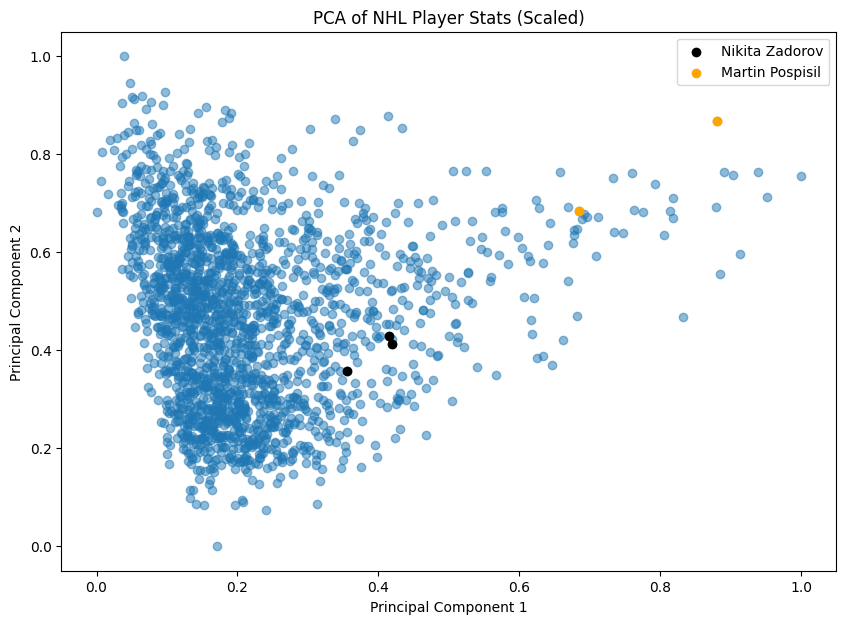

In [205]:
# scatterplot with scaled PCA scores and all Nikita Zadorov and Martin Pospisil players highlighted
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], alpha=0.5)
zadorov_players = df[df.index.str.contains('Nikita Zadorov')]
zadorov_pca_scaled = scaler.transform(pca.transform(zadorov_players[pct_diff_cols].values))
plt.scatter(zadorov_pca_scaled[:, 0], zadorov_pca_scaled[:, 1], color='black', label='Nikita Zadorov')
pospisil_players = df[df.index.str.contains('Martin Pospisil')]
pospisil_pca_scaled = scaler.transform(pca.transform(pospisil_players[pct_diff_cols].values))
plt.scatter(pospisil_pca_scaled[:, 0], pospisil_pca_scaled[:, 1], color='orange', label='Martin Pospisil')
plt.title('PCA of NHL Player Stats (Scaled)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

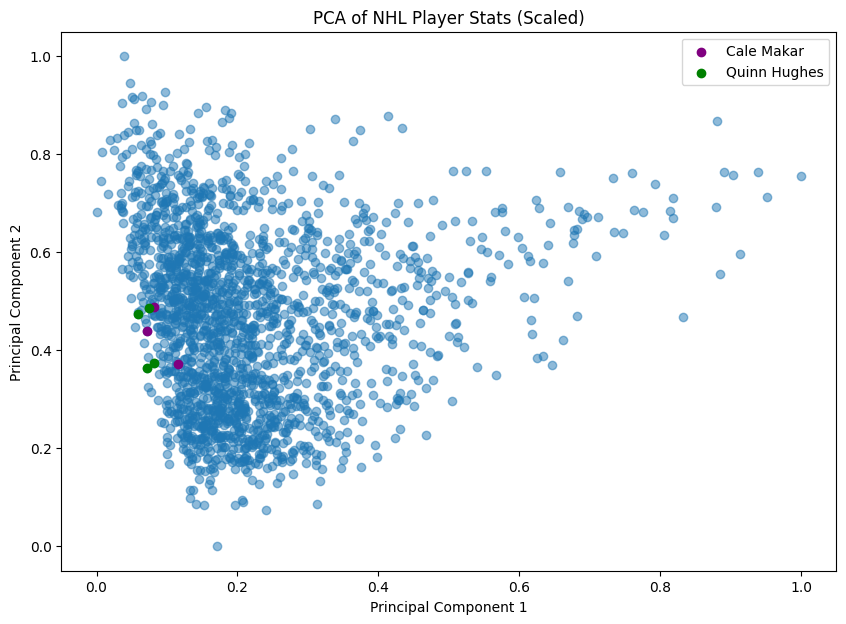

In [208]:
# scatterplot with scaled PCA scores and all Cale Makar and Quinn Hughes players highlighted
plt.figure(figsize=(10, 7))
plt.scatter(X_pca_scaled[:, 0], X_pca_scaled[:, 1], alpha=0.5)
zadorov_players = df[df.index.str.contains('Cale Makar')]
zadorov_pca_scaled = scaler.transform(pca.transform(zadorov_players[pct_diff_cols].values))
plt.scatter(zadorov_pca_scaled[:, 0], zadorov_pca_scaled[:, 1], color='purple', label='Cale Makar')
pospisil_players = df[df.index.str.contains('Quinn Hughes')]
pospisil_pca_scaled = scaler.transform(pca.transform(pospisil_players[pct_diff_cols].values))
plt.scatter(pospisil_pca_scaled[:, 0], pospisil_pca_scaled[:, 1], color='green', label='Quinn Hughes')
plt.title('PCA of NHL Player Stats (Scaled)')
plt.xlabel('Principal Component 1')
plt.ylabel('Principal Component 2')
plt.legend()
plt.show()

In [209]:
# calculate pairwise cosine similarity between all players in pct_diff_cols
from sklearn.metrics.pairwise import cosine_similarity
similarity_matrix = cosine_similarity(df[pct_diff_cols].values)
similarity_df = pd.DataFrame(similarity_matrix, index=df.index, columns=df.index)

In [238]:
# find most similar players to 2026 Quinn Hughes based on cosine similarity
playername = 'Quinn Hughes'
season = '2026'
teamname = 'VAN'
colname = f"{season} | {teamname} | {playername}"
quinn_hughes_similarity = similarity_df.loc[similarity_df.columns.str.contains(colname)]
most_similar_players = quinn_hughes_similarity.sort_values(by=colname, ascending=False).index[1:6]
print("Most similar players to Quinn Hughes:")
print(most_similar_players.tolist())

Most similar players to Quinn Hughes:
['2026 | MIN | Quinn Hughes', '2025 | VAN | Quinn Hughes', '2026 | PIT | Erik Karlsson', '2024 | VAN | Quinn Hughes', '2026 | WPG | Josh Morrissey']


In [239]:
# find most similar players to 2026 Alex Ovechkin based on cosine similarity
playername = 'Alex Ovechkin'
season = '2026'
teamname = 'WSH'
colname = f"{season} | {teamname} | {playername}"
alex_ovechkin_similarity = similarity_df.loc[similarity_df.columns.str.contains(colname)]
most_similar_players = alex_ovechkin_similarity.sort_values(by=colname, ascending=False).index[1:6]
print("Most similar players to Alex Ovechkin:")
print(most_similar_players.tolist())

Most similar players to Alex Ovechkin:
['2025 | WSH | Alex Ovechkin', '2024 | WSH | Alex Ovechkin', '2026 | BOS | Morgan Geekie', '2026 | UTA | Dylan Guenther', '2026 | PHI | Bobby Brink']


In [257]:
# find players who have many hits and goals
hits_goals_players = df[(df['hits_per60_pct_diff'] > 125) & (df['goals_per60_pct_diff'] > 125)]
print("Players with many hits and goals:")
print(hits_goals_players.index.tolist())

Players with many hits and goals:
['2024 | TOR | Bobby McMann', '2024 | OTT | Brady Tkachuk', '2024 | STL | Nathan Walker', '2024 | MIN | Connor Dewar', '2024 | CGY | Blake Coleman', '2025 | SJS | Fabian Zetterlund', '2026 | VEG | TomÃ¡Å¡ Hertl', '2026 | VEG | Ivan Barbashev', '2026 | VAN | Kiefer Sherwood']
